In [ ]:
# 확인
import torch
print(torch.__version__)
print("CUDA 사용가능 여부 : ", torch.cuda.is_abailable())
print("GPU 이름 : ", torch.cuda.get_device_name(0))

2.5.1


AttributeError: module 'torch.cuda' has no attribute 'is_abailable'

In [2]:
!pip install ultralytics

  Using cached py_cpuinfo-9.0.0-py3-none-any.whl.metadata (794 bytes)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached ultralytics_thop-2.0.14-py3-none-any.whl.metadata (9.4 kB)
  Using cached typing_extensions-4.13.2-py3-none-any.whl.metadata (3.0 kB)
  Using cached sympy-1.13.1-py3-none-any.whl.metadata (12 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 21.1 MB/s eta 0:00:00
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached sympy-1.13.1-py3-none-any.whl (6.2 MB)
Using cached typing_extensions-4.13.2-py3-none-any.whl (45 kB)
Using cached ultralytics_thop-2.0.14-py3-none-any.whl (26 kB)
Using cached py_cpuinfo-9.0.0-py3-none-any.whl (22 kB)
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.5.0
    Uninstalling typing_extensions-4.5.0:
      Successfully uninstalled typing_extensions-4.5.0━━━━━━━━━━━━ 1/6 [typing-extensions]
  Attempting uninstall: sympy━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
!pwd

/home/govlept1004/jupyter_home


In [4]:
!mkdir NUMBER

In [5]:
root_folder = '/home/govlept1004/jupyter_home/NUMBER'

In [6]:
cd $root_folder

/home/govlept1004/jupyter_home/NUMBER


In [7]:
!mkdir number_dataset

In [8]:
cd $root_folder/number_dataset

/home/govlept1004/jupyter_home/NUMBER/number_dataset


In [9]:
!mkdir images

In [10]:
!mkdir labels

In [11]:
cd $root_folder

/home/govlept1004/jupyter_home/NUMBER


In [12]:
cd $root_folder/number_dataset/images

/home/govlept1004/jupyter_home/NUMBER/number_dataset/images


In [13]:
cd $root_folder

/home/govlept1004/jupyter_home/NUMBER


In [14]:
!mkdir $root_folder/number_dataset/images/train
!mkdir $root_folder/number_dataset/images/val

!mkdir $root_folder/number_dataset/labels/train
!mkdir $root_folder/number_dataset/labels/val

In [15]:
!pwd

/home/govlept1004/jupyter_home/NUMBER


In [16]:
!git clone https://github.com/ssaru/convert2Yolo.git

Cloning into 'convert2Yolo'...
remote: Enumerating objects: 215, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 215 (delta 38), reused 35 (delta 35), pack-reused 172 (from 1)
Receiving objects: 100% (215/215), 994.67 KiB | 6.63 MiB/s, done.
Resolving deltas: 100% (95/95), done.


In [24]:
# 해당 폴더구조에 이미지 복사
import os
import shutil

# 경로 설정
txt_root = "/home/govlept1004/jupyter_home/NUMBER/Number_devkit/ImageSets/Main"
image_root = "/home/govlept1004/jupyter_home/NUMBERdevkit/JPEGImages"

train_txt_path = os.path.join(txt_root, "train.txt")
val_txt_path = os.path.join(txt_root, "val.txt")

train_image_out = "/home/govlept1004/jupyter_home/NUMBER/number_dataset/images/train"
val_image_out = "/home/govlept1004/jupyter_home/NUMBER/number_dataset/images/val"

# 디렉토리 생성
os.makedirs(train_image_out, exist_ok=True)
os.makedirs(val_image_out, exist_ok=True)

# 파일 복사 함수
def copy_images(txt_path, src_dir, dst_dir):
    with open(txt_path, 'r') as f:
        filenames = [line.strip() for line in f]

    for name in filenames:
        image_file = f"{name}.png"  # 확장자 .jpg 기준 (필요시 .png로 바꾸세요)
        src = os.path.join(src_dir, image_file)
        dst = os.path.join(dst_dir, image_file)
        
        if os.path.exists(src):
            shutil.copy(src, dst)
        else:
            print(f"⚠️ 이미지 없음: {src}")

# 실행
copy_images(train_txt_path, image_root, train_image_out)
copy_images(val_txt_path, image_root, val_image_out)



In [26]:
# 해당 폴더구조에 xml 복사
import os
import shutil

# 경로 설정
txt_root = "/home/govlept1004/jupyter_home/NUMBER/Number_devkit/ImageSets/Main"
xml_root = "/home/govlept1004/jupyter_home/NUMBERdevkit/Annotations"

train_txt_path = os.path.join(txt_root, "train.txt")
val_txt_path = os.path.join(txt_root, "val.txt")

train_xml_out = "/home/govlept1004/jupyter_home/NUMBER/number_dataset/annotations/train"
val_xml_out = "/home/govlept1004/jupyter_home/NUMBER/number_dataset/annotations/val"

# 파일 복사 함수
def copy_xmls(txt_path, src_dir, dst_dir):
    with open(txt_path, 'r') as f:
        filenames = [line.strip() for line in f]

    for name in filenames:
        xml_file = f"{name}.xml"  # 확장자 .jpg 기준 확장자는 변경하기
        src = os.path.join(src_dir, xml_file)
        dst = os.path.join(dst_dir, xml_file)
        
        if os.path.exists(src):
            shutil.copy(src, dst)
        else:
            print(f"⚠️ 이미지 없음: {src}")

# 실행
copy_xmls(train_txt_path, xml_root, train_xml_out)
copy_xmls(val_txt_path, xml_root, val_xml_out)


In [20]:
!head /home/govlept1004/jupyter_home/NUMBER/Number_devkit/ImageSets/Main/train.txt

23396
275
12747
31465
17636
1854
3075
11718
19529
24644


In [23]:
!ls /home/govlept1004/jupyter_home/NUMBER/Number_devkit/JPEGImages/*

/home/govlept1004/jupyter_home/NUMBER/Number_devkit/JPEGImages/10000.png
/home/govlept1004/jupyter_home/NUMBER/Number_devkit/JPEGImages/10009.png
/home/govlept1004/jupyter_home/NUMBER/Number_devkit/JPEGImages/10023.png
/home/govlept1004/jupyter_home/NUMBER/Number_devkit/JPEGImages/10025.png
/home/govlept1004/jupyter_home/NUMBER/Number_devkit/JPEGImages/10033.png
/home/govlept1004/jupyter_home/NUMBER/Number_devkit/JPEGImages/10039.png
/home/govlept1004/jupyter_home/NUMBER/Number_devkit/JPEGImages/10056.png
/home/govlept1004/jupyter_home/NUMBER/Number_devkit/JPEGImages/10058.png
/home/govlept1004/jupyter_home/NUMBER/Number_devkit/JPEGImages/10064.png
/home/govlept1004/jupyter_home/NUMBER/Number_devkit/JPEGImages/10066.png
/home/govlept1004/jupyter_home/NUMBER/Number_devkit/JPEGImages/10067.png
/home/govlept1004/jupyter_home/NUMBER/Number_devkit/JPEGImages/1007.png
/home/govlept1004/jupyter_home/NUMBER/Number_devkit/JPEGImages/10070.png
/home/govlept1004/jupyter_home/NUMBER/Number_devkit/

In [29]:
!find /home/govlept1004/jupyter_home/NUMBER -name "example.py"

/home/govlept1004/jupyter_home/NUMBER/convert2Yolo/example.py


In [30]:
# train용 YOLO txt 파일 생성
!python3 /home/govlept1004/jupyter_home/NUMBER/convert2Yolo/example.py \
--datasets VOC \
--img_path $root_folder/number_dataset/images/train \
--label $root_folder/number_dataset/annotations/train \
--convert_output_path $root_folder/number_dataset/labels/train/ \
--img_type ".png" \
--manifest_path $root_folder/ \
--cls_list_file $root_folder/number.names


VOC Parsing:   |████████████████████████████████████████| 100.0% (4000/4000)  Complete


YOLO Generating:|████████████████████████████████████████| 100.0% (4000/4000)  Complete


YOLO Saving:   |████████████████████████████████████████| 100.0% (4000/4000)  Complete



In [31]:
# VAL용 YOLO txt 파일 생성
!python3 /home/govlept1004/jupyter_home/NUMBER/convert2Yolo/example.py \
--datasets VOC \
--img_path $root_folder/number_dataset/images/val \
--label $root_folder/number_dataset/annotations/val \
--convert_output_path $root_folder/number_dataset/labels/val/ \
--img_type ".png" \
--manifest_path $root_folder/ \
--cls_list_file $root_folder/number.names


VOC Parsing:   |████████████████████████████████████████| 100.0% (400/400)  Complete


YOLO Generating:|████████████████████████████████████████| 100.0% (400/400)  Complete


YOLO Saving:   |████████████████████████████████████████| 100.0% (400/400)  Complete



In [35]:
# 재학습
model = YOLO('yolov8n.pt')

# 재학습
result = model.train(
    data='data.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    workers=4,
    name='yolov8_number'
)

100%|██████████████████████████████████████████████████████████████████████| 6.25M/6.25M [00:04<00:00, 1.34MB/s]


Ultralytics 8.3.133 🚀 Python-3.10.16 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 3070 Ti Laptop GPU, 8192MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8_number, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, p

train: Scanning /home/govlept1004/jupyter_home/NUMBER/number_dataset/labels/train.cache... 4000 images, 0 backgr


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 435.2±549.0 MB/s, size: 8.4 KB)


val: Scanning /home/govlept1004/jupyter_home/NUMBER/number_dataset/labels/val.cache... 400 images, 0 backgrounds


...

    100/100      2.05G      1.189     0.5057       1.29         33        640: 100%|██████████| 250/250 [00:34<0
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13

                   all        400        883      0.932      0.872      0.928      0.459



100 epochs completed in 0.990 hours.
Optimizer stripped from runs/detect/yolov8_number/weights/last.pt, 6.3MB
Optimizer stripped from runs/detect/yolov8_number/weights/best.pt, 6.3MB

Validating runs/detect/yolov8_number/weights/best.pt...
Ultralytics 8.3.133 🚀 Python-3.10.16 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 3070 Ti Laptop GPU, 8192MiB)
Model summary (fused): 72 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13


                   all        400        883      0.899      0.906      0.939       0.49
                     0         61         63      0.929      0.905      0.967      0.542
                     1        126        145      0.881      0.883      0.903      0.405
                     2        119        132      0.919      0.909      0.969      0.526
                     3         96        102      0.833      0.882      0.884      0.443
                     4         92         98      0.978      0.918      0.962      0.513
                     5         79         83      0.855      0.952      0.938      0.503
                     6         76         79      0.936      0.926      0.975      0.525
                     7         59         62      0.904       0.91      0.934      0.507
                     8         54         58      0.911      0.887      0.943       0.45
                     9         60         61      0.848      0.885      0.915      0.485
Speed: 0.1ms preproce

In [36]:
import cv2
import torch
from ultralytics import YOLO

In [37]:
!pwd

/home/govlept1004/jupyter_home/NUMBER


In [53]:
# 학습된 모델 불러오기 (예: best.pt 또는 최종 저장된 weight 경로)
model = YOLO('/home/govlept1004/jupyter_home/NUMBER/runs/detect/yolov8_number/weights/best.pt')

In [64]:
# 이미지가 있는 폴더 경로 설정
image_folder = '/home/govlept1004/jupyter_home/NUMBERdevkit/number_detect_image'

In [65]:
# 폴더 내 이미지 목록 가져오기
image_files = [f for f in os.listdir(image_folder) if f.endswith(('.png'))]
image_files = image_files[:] 


image 1/1 /home/govlept1004/jupyter_home/NUMBERdevkit/number_detect_image/2621.png: 160x640 1 0, 2 3s, 1 8, 11.7ms
Speed: 2.8ms preprocess, 11.7ms inference, 1.7ms postprocess per image at shape (1, 3, 160, 640)


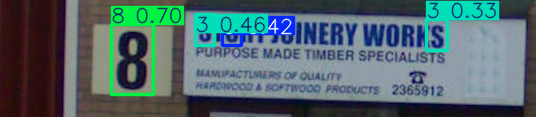


image 1/1 /home/govlept1004/jupyter_home/NUMBERdevkit/number_detect_image/2868.png: 256x640 (no detections), 21.2ms
Speed: 1.7ms preprocess, 21.2ms inference, 0.6ms postprocess per image at shape (1, 3, 256, 640)


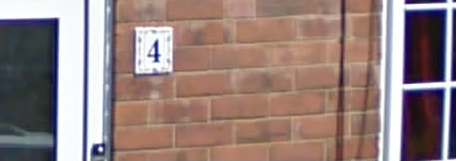


image 1/1 /home/govlept1004/jupyter_home/NUMBERdevkit/number_detect_image/7204.png: 320x640 1 4, 1 7, 22.3ms
Speed: 1.8ms preprocess, 22.3ms inference, 8.9ms postprocess per image at shape (1, 3, 320, 640)


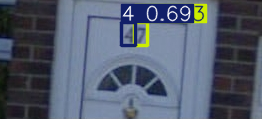


image 1/1 /home/govlept1004/jupyter_home/NUMBERdevkit/number_detect_image/11664.png: 288x640 3 5s, 21.5ms
Speed: 3.8ms preprocess, 21.5ms inference, 1.9ms postprocess per image at shape (1, 3, 288, 640)


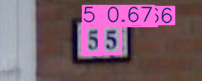


image 1/1 /home/govlept1004/jupyter_home/NUMBERdevkit/number_detect_image/9942.png: 256x640 (no detections), 12.1ms
Speed: 3.7ms preprocess, 12.1ms inference, 0.7ms postprocess per image at shape (1, 3, 256, 640)


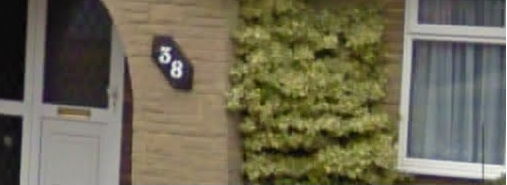


image 1/1 /home/govlept1004/jupyter_home/NUMBERdevkit/number_detect_image/5877.png: 288x640 2 2s, 13.3ms
Speed: 7.1ms preprocess, 13.3ms inference, 1.9ms postprocess per image at shape (1, 3, 288, 640)


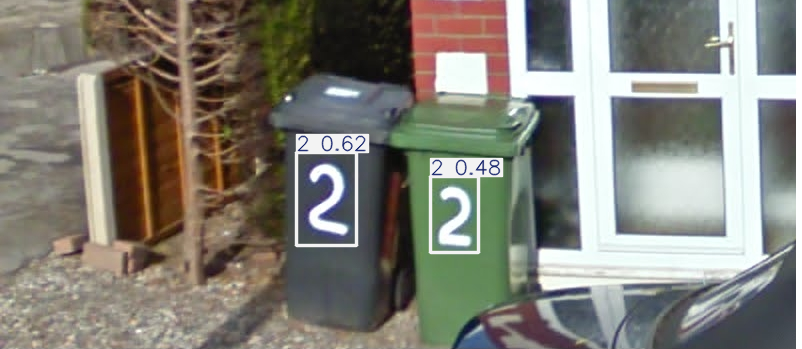


image 1/1 /home/govlept1004/jupyter_home/NUMBERdevkit/number_detect_image/12286.png: 224x640 1 0, 9.4ms
Speed: 2.9ms preprocess, 9.4ms inference, 1.5ms postprocess per image at shape (1, 3, 224, 640)


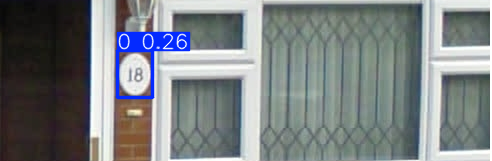


image 1/1 /home/govlept1004/jupyter_home/NUMBERdevkit/number_detect_image/11660.png: 256x640 2 1s, 1 8, 9.7ms
Speed: 1.6ms preprocess, 9.7ms inference, 1.6ms postprocess per image at shape (1, 3, 256, 640)


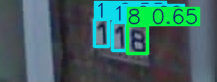


image 1/1 /home/govlept1004/jupyter_home/NUMBERdevkit/number_detect_image/7706.png: 288x640 (no detections), 18.2ms
Speed: 1.6ms preprocess, 18.2ms inference, 0.7ms postprocess per image at shape (1, 3, 288, 640)


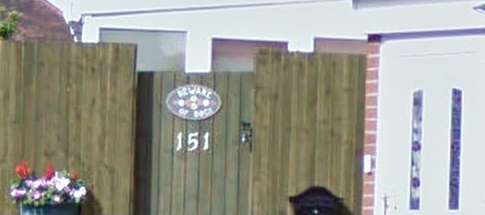


image 1/1 /home/govlept1004/jupyter_home/NUMBERdevkit/number_detect_image/10975.png: 288x640 1 2, 1 9, 16.8ms
Speed: 7.3ms preprocess, 16.8ms inference, 1.9ms postprocess per image at shape (1, 3, 288, 640)


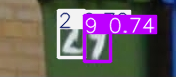

<Figure size 1500x1000 with 10 Axes>

In [67]:
import matplotlib.pyplot as plt

# 예측 결과 시각화
plt.figure(figsize=(15, 10))  # 전체 출력 화면 크기 설정
for idx, image_file in enumerate(image_files):
    img_path = os.path.join(image_folder, image_file)
    
    # 이미지 예측
    results = model(img_path)
    
    # 이미지 시각화
    plt.subplot(2, 5, idx + 1)  # 2행 5열로 배치 (10개 이미지)
    results[0].show()  # 예측된 결과 시각화 (각각의 이미지에 대해)
    plt.title(image_file)  # 이미지 파일명 표시

plt.tight_layout()
plt.show()